In [39]:
#importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns

In [38]:
#loading crime dataset
crime = pd.read_csv('crime_data.csv')
#printing the first few rows
crime.head()

/tmp/ipykernel_220/2149843072.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  crime = pd.read_csv('crime_data.csv')


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
0,201563066,9199,260006308,02/10/2026 07:42:38 PM,90Z,1,Crime Against Society,All Other Offenses,POLICE INFORMATION,SILVER SPRING,...,NaN,FIDLER,NaN,LA,02/10/2026 07:42:00 PM,NaN,38.99610,-77.0298,3D,POINT (-77.0298 38.9961)
1,201563057,9108,260006317,02/10/2026 07:06:31 PM,90Z,1,Crime Against Society,All Other Offenses,RECOVERED PROPERTY - MONT CO.,BETHESDA,...,NaN,EAST WEST,NaN,HWY,02/10/2026 07:06:00 PM,NaN,38.98865,-77.0735,2D,POINT (-77.0735 38.9887)
2,201563043,9109,260006301,02/10/2026 06:55:48 PM,90Z,1,Crime Against Society,All Other Offenses,RECOVERED PROPERTY - OTHER,TAKOMA PARK,...,NaN,NEW HAMPSHIRE,NaN,AVE,02/10/2026 06:55:00 PM,NaN,38.98337,-76.9883,TPPD,POINT (-76.9883 38.9834)
3,201563053,2308,260006298,02/10/2026 05:53:13 PM,23D,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,...,NaN,NICHOLSON,NaN,LA,02/10/2026 05:53:00 PM,NaN,39.04554,-77.1048,2D,POINT (-77.1048 39.0455)
4,201563053,3550,260006298,02/10/2026 05:53:13 PM,35B,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,BETHESDA,...,NaN,NICHOLSON,NaN,LA,02/10/2026 05:53:00 PM,NaN,39.04554,-77.1048,2D,POINT (-77.1048 39.0455)


In [6]:
#checking the dimension
crime.shape

(315232, 30)

In [8]:
#checking data types 

crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315232 entries, 0 to 315231
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             315232 non-null  int64  
 1   Offence Code            315232 non-null  object 
 2   CR Number               315232 non-null  int64  
 3   Dispatch Date / Time    315232 non-null  object 
 4   NIBRS Code              315232 non-null  object 
 5   Victims                 315232 non-null  int64  
 6   Crime Name1             315232 non-null  object 
 7   Crime Name2             315232 non-null  object 
 8   Crime Name3             315232 non-null  object 
 9   Police District Name    313937 non-null  object 
 10  Block Address           291272 non-null  object 
 11  City                    315212 non-null  object 
 12  State                   308838 non-null  object 
 13  Zip Code                315007 non-null  float64
 14  Agency              

In [9]:
#checking missing values
crime.isna().sum()

Incident ID                    0
Offence Code                   0
CR Number                      0
Dispatch Date / Time           0
NIBRS Code                     0
Victims                        0
Crime Name1                    0
Crime Name2                    0
Crime Name3                    0
Police District Name        1295
Block Address              23960
City                          20
State                       6394
Zip Code                     225
Agency                         0
Place                          0
Sector                         0
Beat                           0
PRA                            1
Address Number             23866
Street Prefix             300994
Street Name                 1225
Street Suffix             311646
Street Type                 1325
Start_Date_Time                0
End_Date_Time             179091
Latitude                       0
Longitude                      0
Police District Number         0
Location                       0
dtype: int

In [11]:
#imputing missing values for important variables 

crime['Zip Code'].fillna(crime['Zip Code'].mode()[0], inplace=True)

crime['Police District Name'].fillna(crime['Police District Name'].mode()[0], inplace=True)

/tmp/ipykernel_220/3881039602.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crime['Police District Name'].fillna(crime['Police District Name'].mode()[0], inplace=True)


In [12]:
#converting zipcode to an int 
crime['Zip Code']=crime['Zip Code'].astype('int')

In [15]:
#subsetting the data to retain only important variables 

subset1 = crime[['Zip Code', 'Latitude', 'Longitude','Location', 'Police District Name','Police District Number', 'Start_Date_Time', "Victims"]]
subset1.head()

,Zip Code,Latitude,Longitude,Location,Police District Name,Police District Number,Start_Date_Time,Victims
0,20910.0,38.99610,-77.0298,POINT (-77.0298 38.9961),SILVER SPRING,3D,02/10/2026 07:42:00 PM,1
1,20815.0,38.98865,-77.0735,POINT (-77.0735 38.9887),BETHESDA,2D,02/10/2026 07:06:00 PM,1
2,20912.0,38.98337,-76.9883,POINT (-76.9883 38.9834),TAKOMA PARK,TPPD,02/10/2026 06:55:00 PM,1
3,20895.0,39.04554,-77.1048,POINT (-77.1048 39.0455),BETHESDA,2D,02/10/2026 05:53:00 PM,1
4,20895.0,39.04554,-77.1048,POINT (-77.1048 39.0455),BETHESDA,2D,02/10/2026 05:53:00 PM,1


In [18]:
#checking for duplicates 
subset1.duplicated().sum()
subset1 = subset1.drop_duplicates()

In [20]:
#Loading income and population data 
pop_inc = pd.read_csv('census_data.csv')
pop_inc

,Year,District,Income,Population
0,2019,District 1,"131,588","21,993"
1,2020,District 1,"139,693","22,690"
2,2021,District 1,"140,270","22,672"
3,2022,District 1,"146,250","22,114"
4,2023,District 1,"154,606","22,225"
...,...,...,...,...
73,2020,District 13,"92,037","269,691"
74,2021,District 13,"97,901","272,874"
75,2022,District 13,"104,294","273,232"
76,2023,District 13,"108,229","272,679"


This data revealed that there is a mismatch between census district(13 in total) and police district(6 in total). 

## How have crime evolved throughout the years?

/tmp/ipykernel_220/3719795427.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = subset1.resample('M').size()


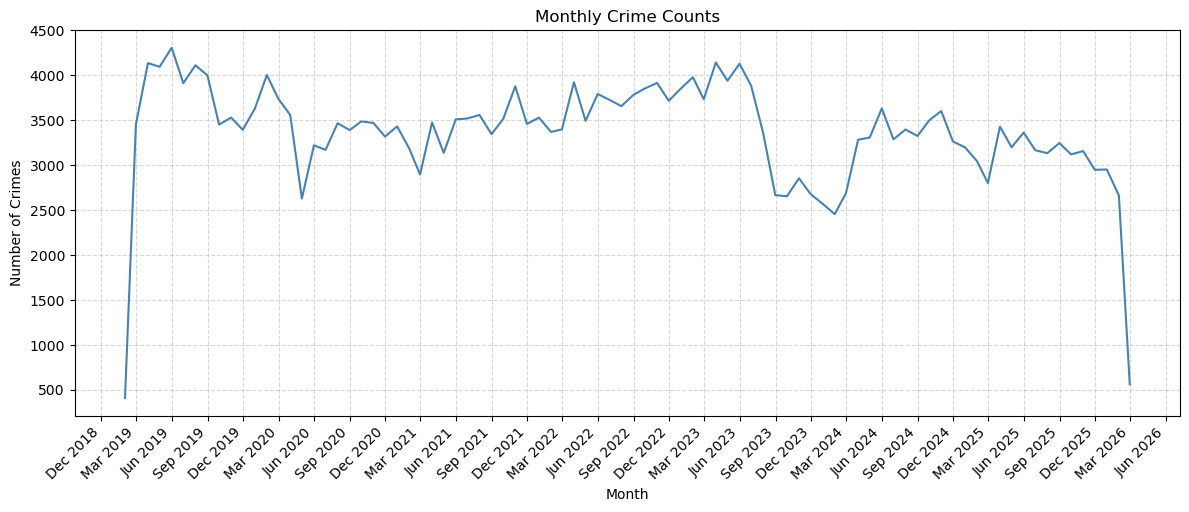

In [22]:
#converting crime dates to an actual datetime object 
subset1['Start_Date_Time'] = pd.to_datetime(subset1['Start_Date_Time'], format='%m/%d/%Y %I:%M:%S %p')
#sorting the values
subset1 = subset1.sort_values('Start_Date_Time')
#setting the dates as index
subset1.set_index('Start_Date_Time', inplace=True)
#dividing by month 
monthly_counts = subset1.resample('M').size()
#excluding any dates before 2019
monthly_counts = monthly_counts[monthly_counts.index>='2019-01-01']

#plotting
plt.figure(figsize=(12, 5))
plt.plot(monthly_counts.index, monthly_counts.values, linewidth=1.5, color='steelblue')
plt.title("Monthly Crime Counts")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.show()

In [40]:
#converting Year as an integer
pop_inc['Year'].astype(int)
#converting income as an integer
pop_inc["Income"] = (
    pop_inc["Income"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

AttributeError: Can only use .str accessor with string values!

In [41]:
#converting population as an integer
pop_inc["Population"] = (
    pop_inc["Population"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

AttributeError: Can only use .str accessor with string values!

In [44]:
crosswalk = {
    'District 1': '5D',
    'District 2': '5D', 
    'District 3': '1D',
    'District 4': '1D', 
   'District 5': '3D', 
    'District 6': '1D',
    'District 7': '2D', 
    'District 8': '4D',
   'District 9': '6D',
    'District 10': '2D',
    'District 11': '5D', 
    'District 12': '5D',
    'District 13': '4D'
}

# 2. Map the 13 districts to the 6 districts
pop_inc['Police_District'] = pop_inc['District'].map(crosswalk)

pop_inc

,Year,District,Income,Population,Police_District
0,2019,District 1,131588,21993,5D
1,2020,District 1,139693,22690,5D
2,2021,District 1,140270,22672,5D
3,2022,District 1,146250,22114,5D
4,2023,District 1,154606,22225,5D
...,...,...,...,...,...
73,2020,District 13,92037,269691,4D
74,2021,District 13,97901,272874,4D
75,2022,District 13,104294,273232,4D
76,2023,District 13,108229,272679,4D


## How have Income evolved?

Text(0.5, 1.0, 'Evolution of Income by district & year')

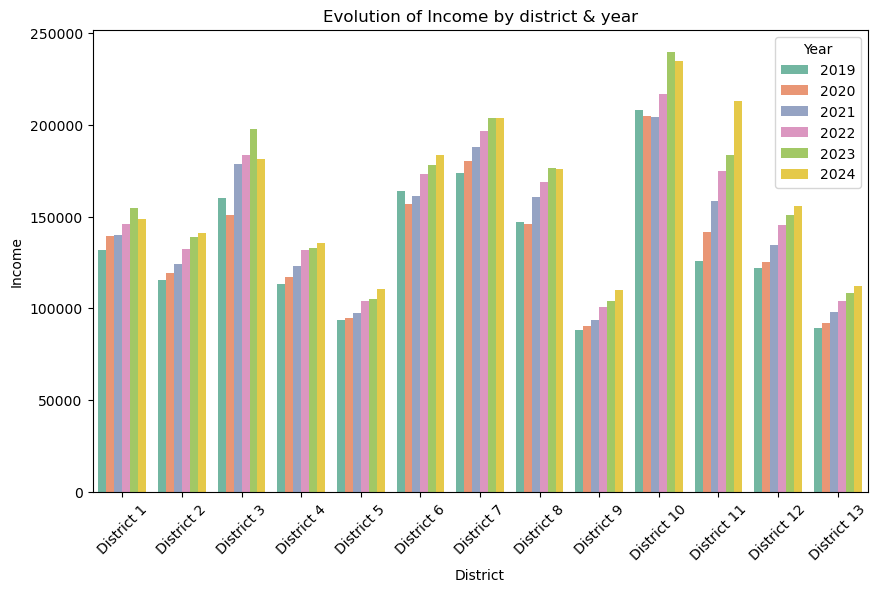

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x='District', y='Income', data=pop_inc, hue='Year', palette='Set2')
plt.xticks(rotation=45)
plt.title('Evolution of Income by district & year')

## How have population evolved?

Text(0.5, 1.0, 'Evolution of Population by district & year')

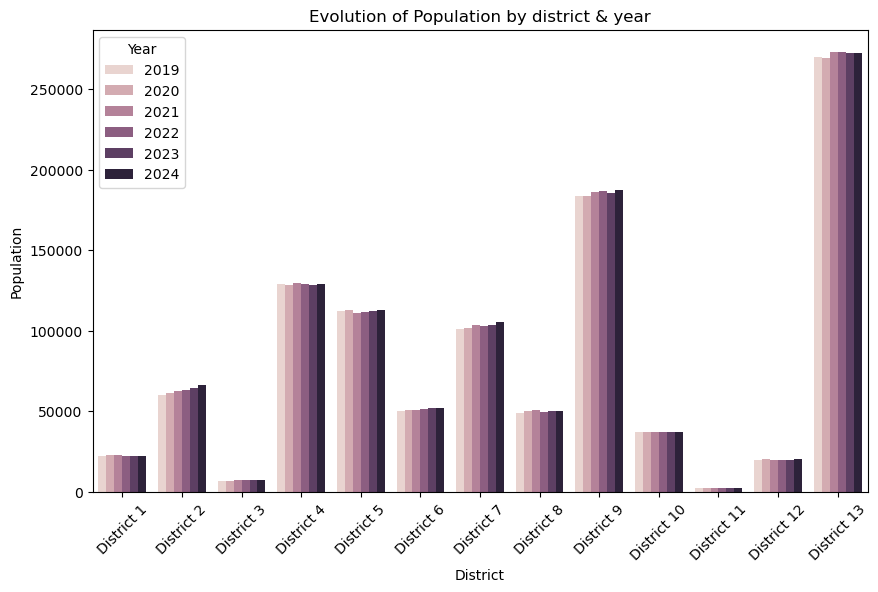

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(x='District', y='Population', data=pop_inc, hue='Year')
plt.xticks(rotation=45)
plt.title('Evolution of Population by district & year')